In [1]:
!pip install optuna

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/d9/dd/0b593d1a5ee431b33a1fdf4ddb5911c312ed3bb598ef9e17457af2ee7b34/optuna-4.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for alembic>=1.5.0 from https://files.pythonhosted.org/packages/31/59/565286efff3692c5716c212202af61466480f6357c4ae3089d4453bff1f3/alembic-1.16.1-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/e3/51/9b208e85196941db2f0654ad0357ca6388ab3ed67efdbfc799f35d1f83aa/colorlog-6.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for Mako from https://files.pythonhosted.org/packages/87/fb/99f81ac72ae23375f22b7afdb7642aba97c00a713c217124420147681a2f/mako-1.3.10-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/386.6 kB ? eta -:--:--
   --------- ------------------------------ 92.2/386.6 kB 1.7 MB/s eta 0:00:01
   -------------------------------------- - 368.6/3

In [1]:
### CITATION ###
# Hyperparameter tuning implemented with help from tutorials provided with Optuna package
# https://optuna.org/
# https://optuna.readthedocs.io/en/stable/index.html

In [10]:
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np
import time
import random
import optuna
from optuna.samplers import TPESampler
from gwgraphs import *
from visualizations import GCNResultsVisualizer, get_model_probabilities

In [11]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [12]:
def read_graph_data():
    # Read the adjacency matrix (edges)
    with open("BZR_A.txt", "r") as f:
        edges = [tuple(map(int, line.split(','))) for line in f]

    # Read graph indicators
    with open("BZR_graph_indicator.txt", "r") as f:
        graph_indicators = [int(line.strip()) for line in f if line.strip()]

    # Read graph labels
    with open("BZR_graph_labels.txt", "r") as f:
        graph_labels = [int(line.strip()) for line in f]

    # Read node labels
    with open("BZR_node_labels.txt", "r") as f:
        node_labels = [int(line.strip()) for line in f]

    # Read node attributes
    with open("BZR_node_attributes.txt", "r") as f:
        node_attributes = [
            list(map(float,
                     line.strip().split(','))) for line in f if line.strip()
        ]

    return edges, graph_indicators, graph_labels, node_labels, node_attributes


def construct_networkx_graph(edges, graph_indicators, graph_labels,
                             node_labels, node_attributes):
    graphs = {}
    for node_id, graph_id in enumerate(graph_indicators, start=1):
        if graph_id not in graphs:
            graphs[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])

    for edge in edges:
        node1, node2 = edge
        graph_id = graph_indicators[
            node1 - 1]  # Determine which graph the edge belongs to
        graphs[graph_id].add_edge(node1, node2)

    for node_id, (graph_id, node_label,
                  node_attr) in enumerate(zip(graph_indicators, node_labels,
                                              node_attributes),
                                          start=1):
        graphs[graph_id].nodes[node_id]['label'] = node_label
        graphs[graph_id].nodes[node_id]['attributes'] = node_attr

    return graphs


def compute_bzr_distance_matrix(graph):
    num_nodes = len(graph.nodes)
    distance_matrix = np.full((num_nodes, num_nodes), 10000.0)

    # Get the correct node indices to be used for indexing the matrix
    node_list = list(graph.nodes())
    node_index = {node: i for i, node in enumerate(node_list)}

    for node in graph.nodes:
        lengths = nx.shortest_path_length(graph, source=node, weight="weight")

        for target, length in lengths.items():
            if target in node_index:
                distance_matrix[node_index[node], node_index[target]] = length

    return distance_matrix

In [13]:
class GraphNeuralNetwork(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3):
        super(GraphNeuralNetwork, self).__init__()

        self.num_layers = num_layers
        self.convs = nn.ModuleList()

        # First layer
        self.convs.append(GCNConv(input_dim, hidden_dim))

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))

        # Last layer
        self.convs.append(GCNConv(hidden_dim, hidden_dim))

        # Classifier
        self.classifier = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, edge_index, batch):
        # Apply GCN layers
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = self.dropout(x)

        # Global pooling to get graph-level representation
        x = global_mean_pool(x, batch)

        # Final classification
        x = self.classifier(x)

        return x


def train_model(model, train_loader, optimizer, criterion, device):
    """Function to train the model for one epoch."""
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass
        out = model(batch.x, batch.edge_index, batch.batch)

        # Convert labels from {-1, 1} to {0,1} for cross-entropy loss
        labels = (batch.y + 1) // 2

        loss = criterion(out, labels.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)


def evaluate_model(model, test_loader, device):
    """Function to evaluate the model."""
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)

            # Get predictions
            pred = torch.argmax(out, dim=1)
            # Convert back to {-1,1} labels
            pred = pred * 2 - 1

            predictions.extend(pred.cpu().numpy())
            true_labels.extend(batch.y.cpu().numpy())

        return np.array(predictions), np.array(true_labels)


def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics"""
    # Overall accuracy
    overall_acc = accuracy_score(y_true, y_pred)

    # By-class accuracy
    class_1_mask = y_true == 1
    class_neg1_mask = y_true == -1

    class_1_acc = accuracy_score(
        y_true[class_1_mask],
        y_pred[class_1_mask]) if np.sum(class_1_mask) > 0 else 0
    class_neg1_acc = accuracy_score(
        y_true[class_neg1_mask],
        y_pred[class_neg1_mask]) if np.sum(class_neg1_mask) > 0 else 0

    # F1 score
    f1 = f1_score(y_true, y_pred, average='weighted')

    return overall_acc, class_1_acc, class_neg1_acc, f1


def objective(trial, full_graph_data, labels, device, input_dim, hidden_dim, output_dim):
    """Objective function for Bayesian optimization"""
    # Suggest hyperparameters
    num_epochs = trial.suggest_int('num_epochs', 20, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    # 5-fold cross validation for this trial
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    fold_scores = []
    
    for fold, (train_idx, test_idx) in enumerate(kfold.split(full_graph_data, labels)):
        # Split data
        train_graphs = [full_graph_data[i] for i in train_idx]
        test_graphs = [full_graph_data[i] for i in test_idx]
        
        # Create data loaders
        train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)
        
        # Initialize model
        model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()
        
        # Training loop
        for epoch in range(num_epochs):
            train_loss = train_model(model, train_loader, optimizer, criterion, device)
        
        # Evaluation
        y_pred, y_true = evaluate_model(model, test_loader, device)
        overall_acc, _, _, _ = calculate_metrics(y_true, y_pred)
        fold_scores.append(overall_acc)
        
        # Report intermediate objective value for pruning
        trial.report(np.mean(fold_scores[:fold+1]), fold)
        
        # Handle pruning based on the intermediate value
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    return np.mean(fold_scores)


def networkx_to_pyg(nx_graph, label, num_features):
    """Convert NetworkX graph to PyTorch Geometric Data object"""
    num_nodes = len(nx_graph.nodes)

    # Extract node features from the graph's node attributes
    node_features = []
    node_list = sorted(nx_graph.nodes())  # Ensure consistent ordering
    
    for node in node_list:
        if 'attributes' in nx_graph.nodes[node]:
            # Use the actual node attributes from the BZR dataset
            node_features.append(nx_graph.nodes[node]['attributes'])
        else:
            # Fallback to zero features if attributes are missing
            node_features.append([0.0] * num_features)
    
    # Convert to tensor
    x = torch.tensor(node_features, dtype=torch.float32)

    # Convert edges to tensor format - need to map node IDs to indices
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}
    edge_list = list(nx_graph.edges())
    
    if len(edge_list) == 0:
        # Handle graphs with no edges
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        # Map node IDs to indices for edge_index
        mapped_edges = [(node_to_idx[u], node_to_idx[v]) for u, v in edge_list]
        edge_index = torch.tensor(mapped_edges, dtype=torch.long).t().contiguous()

    # Convert label to tensor
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

In [14]:
edges, graph_indicators, graph_labels, node_labels, node_attributes = read_graph_data()
graphs = construct_networkx_graph(edges, graph_indicators, graph_labels,
                                node_labels, node_attributes)
for graph_id, graph in graphs.items():
    print(
        f"Graph ID: {graph_id}, number of nodes: {graph.number_of_nodes()}, label: {graph.graph['label']}"
        )
total_avg, class_averages = compute_averages(graphs)
print(f"Average number of nodes in entire dataset: {total_avg}")
print("Average number of nodes for each class:")
for class_label, avg_nodes in class_averages.items():
        print(f"  Class {class_label}: {avg_nodes}")

Graph ID: 1, number of nodes: 30, label: -1
Graph ID: 2, number of nodes: 33, label: -1
Graph ID: 3, number of nodes: 30, label: -1
Graph ID: 4, number of nodes: 33, label: -1
Graph ID: 5, number of nodes: 30, label: -1
Graph ID: 6, number of nodes: 33, label: -1
Graph ID: 7, number of nodes: 30, label: -1
Graph ID: 8, number of nodes: 30, label: -1
Graph ID: 9, number of nodes: 33, label: -1
Graph ID: 10, number of nodes: 30, label: -1
Graph ID: 11, number of nodes: 30, label: -1
Graph ID: 12, number of nodes: 30, label: -1
Graph ID: 13, number of nodes: 33, label: -1
Graph ID: 14, number of nodes: 33, label: -1
Graph ID: 15, number of nodes: 33, label: -1
Graph ID: 16, number of nodes: 33, label: -1
Graph ID: 17, number of nodes: 32, label: -1
Graph ID: 18, number of nodes: 32, label: -1
Graph ID: 19, number of nodes: 32, label: -1
Graph ID: 20, number of nodes: 35, label: -1
Graph ID: 21, number of nodes: 32, label: -1
Graph ID: 22, number of nodes: 35, label: -1
Graph ID: 23, numbe

NameError: name 'compute_averages' is not defined

In [15]:
graphs_list = []
labels_list = []
for graph_id, graph in graphs.items():
    # Add the graph object to the list
    graphs_list.append(graph)

    # Extract the label and add to the label list
    label = graph.graph['label']
    labels_list.append(label)

# Convert graphs into pairwise distance matrices
distance_matrices = [compute_bzr_distance_matrix(graph) for graph in graphs_list]

In [16]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model parameters
input_dim = 3  # Number of node features; BZR dataset has 3D node attributes
hidden_dim = 64  # defines the number of neurons in the GCN layers
output_dim = 2  # Binary classification, so set to 2

# Convert NetworkX graphs to PyTorch Geometric Data objects
full_graph_data = []
for graph_id, nx_graph in graphs.items():
    label = nx_graph.graph['label']
    pyg_data = networkx_to_pyg(nx_graph, label, input_dim)
    full_graph_data.append(pyg_data)

# Extract labels for reference
labels = [data.y.item() for data in full_graph_data]
labels = np.array(labels)
print("BZR dataset processed successfully.")

Using device: cpu
BZR dataset processed successfully.


In [17]:
print("\nStarting Bayesian Optimization for Hyperparameter Tuning...")
start_time = time.time()

# Create Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
)

# Optimize hyperparameters
study.optimize(
    lambda trial: objective(trial, full_graph_data, labels, device, input_dim, hidden_dim, output_dim),
    n_trials=50 
)

optimization_time = time.time() - start_time

# Print best hyperparameters
print("\n" + "=" * 60)
print("BAYESIAN OPTIMIZATION RESULTS")
print("=" * 60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best accuracy: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

print(f"\nOptimization time: {optimization_time:.2f} seconds")

# Train final model with best hyperparameters
print("\n" + "=" * 60)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("=" * 60)

best_params = study.best_trial.params
final_num_epochs = best_params['num_epochs']
final_learning_rate = best_params['learning_rate']
final_batch_size = best_params['batch_size']

# 5-fold cross validation with best parameters
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_results = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(full_graph_data, labels)):
    print(f"\n--- Final Training Fold {fold + 1}/5 ---")
    
    # Split data
    train_graphs = [full_graph_data[i] for i in train_idx]
    test_graphs = [full_graph_data[i] for i in test_idx]
    
    # Create data loaders
    train_loader = DataLoader(train_graphs, batch_size=final_batch_size, shuffle=True)
    test_loader = DataLoader(test_graphs, batch_size=final_batch_size, shuffle=False)
    
    # Initialize model
    model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=final_learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    for epoch in range(final_num_epochs):
        train_loss = train_model(model, train_loader, optimizer, criterion, device)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{final_num_epochs}, Loss: {train_loss:.4f}")
    
    # Final evaluation
    y_pred, y_true = evaluate_model(model, test_loader, device)
    overall_acc, class_1_acc, class_neg1_acc, f1 = calculate_metrics(y_true, y_pred)
    
    results = {
        'fold': fold + 1,
        'overall_accuracy': overall_acc,
        'class_1_accuracy': class_1_acc,
        'class_-1_accuracy': class_neg1_acc,
        'f1_score': f1
    }
    
    all_results.append(results)
    
    print(f"Results for Fold {fold + 1}:")
    print(f"  Overall Accuracy: {overall_acc:.4f}")
    print(f"  Class +1 Accuracy: {class_1_acc:.4f}")
    print(f"  Class -1 Accuracy: {class_neg1_acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")

# Calculate final average metrics
avg_overall_acc = np.mean([r['overall_accuracy'] for r in all_results])
avg_class_1_acc = np.mean([r['class_1_accuracy'] for r in all_results])
avg_class_neg1_acc = np.mean([r['class_-1_accuracy'] for r in all_results])
avg_f1 = np.mean([r['f1_score'] for r in all_results])

std_overall_acc = np.std([r['overall_accuracy'] for r in all_results])
std_class_1_acc = np.std([r['class_1_accuracy'] for r in all_results])
std_class_neg1_acc = np.std([r['class_-1_accuracy'] for r in all_results])
std_f1 = np.std([r['f1_score'] for r in all_results])

total_time = time.time() - start_time

print("\n" + "=" * 60)
print("FINAL RESULTS WITH OPTIMIZED HYPERPARAMETERS")
print("=" * 60)
print(f"Best hyperparameters used:")
print(f"  Epochs: {final_num_epochs}")
print(f"  Learning Rate: {final_learning_rate:.6f}")
print(f"  Batch Size: {final_batch_size}")
print(f"\nFinal Cross-Validation Results:")
print(f"Average Overall Accuracy: {avg_overall_acc:.4f} ± {std_overall_acc:.4f}")
print(f"Average Class +1 Accuracy: {avg_class_1_acc:.4f} ± {std_class_1_acc:.4f}")
print(f"Average Class -1 Accuracy: {avg_class_neg1_acc:.4f} ± {std_class_neg1_acc:.4f}")
print(f"Average F1 Score: {avg_f1:.4f} ± {std_f1:.4f}")
print(f"\nTotal Time (Optimization + Final Training): {total_time:.2f} seconds")

[I 2025-07-28 17:50:23,040] A new study created in memory with name: no-name-35bad70b-ab13-423d-9d29-b098fecbb502



Starting Bayesian Optimization for Hyperparameter Tuning...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader


BAYESIAN OPTIMIZATION RESULTS
Best trial: 38
Best accuracy: 0.8496
Best hyperparameters:
  num_epochs: 70
  learning_rate: 0.007898469069882834
  batch_size: 16

Optimization time: 1411.49 seconds

TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

--- Final Training Fold 1/5 ---
Epoch 10/70, Loss: 0.5063
Epoch 20/70, Loss: 0.4788
Epoch 30/70, Loss: 0.4488
Epoch 40/70, Loss: 0.4010
Epoch 50/70, Loss: 0.3938
Epoch 60/70, Loss: 0.4199
Epoch 70/70, Loss: 0.3901
Results for Fold 1:
  Overall Accuracy: 0.8537
  Class +1 Accuracy: 0.4444
  Class -1 Accuracy: 0.9688
  F1 Score: 0.8371

--- Final Training Fold 2/5 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


...

Epoch 10/70, Loss: 0.4653
Epoch 20/70, Loss: 0.4177
Epoch 30/70, Loss: 0.3972
Epoch 40/70, Loss: 0.3874
Epoch 50/70, Loss: 0.3572
Epoch 60/70, Loss: 0.3708
Epoch 70/70, Loss: 0.3645
Results for Fold 8:
  Overall Accuracy: 0.7750
  Class +1 Accuracy: 0.1250
  Class -1 Accuracy: 0.9375
  F1 Score: 0.7320

--- Final Training Fold 9/5 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 10/70, Loss: 0.4769
Epoch 20/70, Loss: 0.4242
Epoch 30/70, Loss: 0.4076
Epoch 40/70, Loss: 0.3915
Epoch 50/70, Loss: 0.4215
Epoch 60/70, Loss: 0.3828
Epoch 70/70, Loss: 0.3984
Results for Fold 9:
  Overall Accuracy: 0.8250
  Class +1 Accuracy: 0.1250
  Class -1 Accuracy: 1.0000
  F1 Score: 0.7656

--- Final Training Fold 10/5 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 10/70, Loss: 0.4751
Epoch 20/70, Loss: 0.3920
Epoch 30/70, Loss: 0.4308
Epoch 40/70, Loss: 0.3972
Epoch 50/70, Loss: 0.4106
Epoch 60/70, Loss: 0.3867
Epoch 70/70, Loss: 0.3391
Results for Fold 10:
  Overall Accuracy: 0.8000
  Class +1 Accuracy: 0.1111
  Class -1 Accuracy: 1.0000
  F1 Score: 0.7314

FINAL RESULTS WITH OPTIMIZED HYPERPARAMETERS
Best hyperparameters used:
  Epochs: 70
  Learning Rate: 0.007898
  Batch Size: 16

Final Cross-Validation Results:
Average Overall Accuracy: 0.8249 ± 0.0443
Average Class +1 Accuracy: 0.3153 ± 0.1922
Average Class -1 Accuracy: 0.9625 ± 0.0437
Average F1 Score: 0.7920 ± 0.0594

Total Time (Optimization + Final Training): 1450.82 seconds


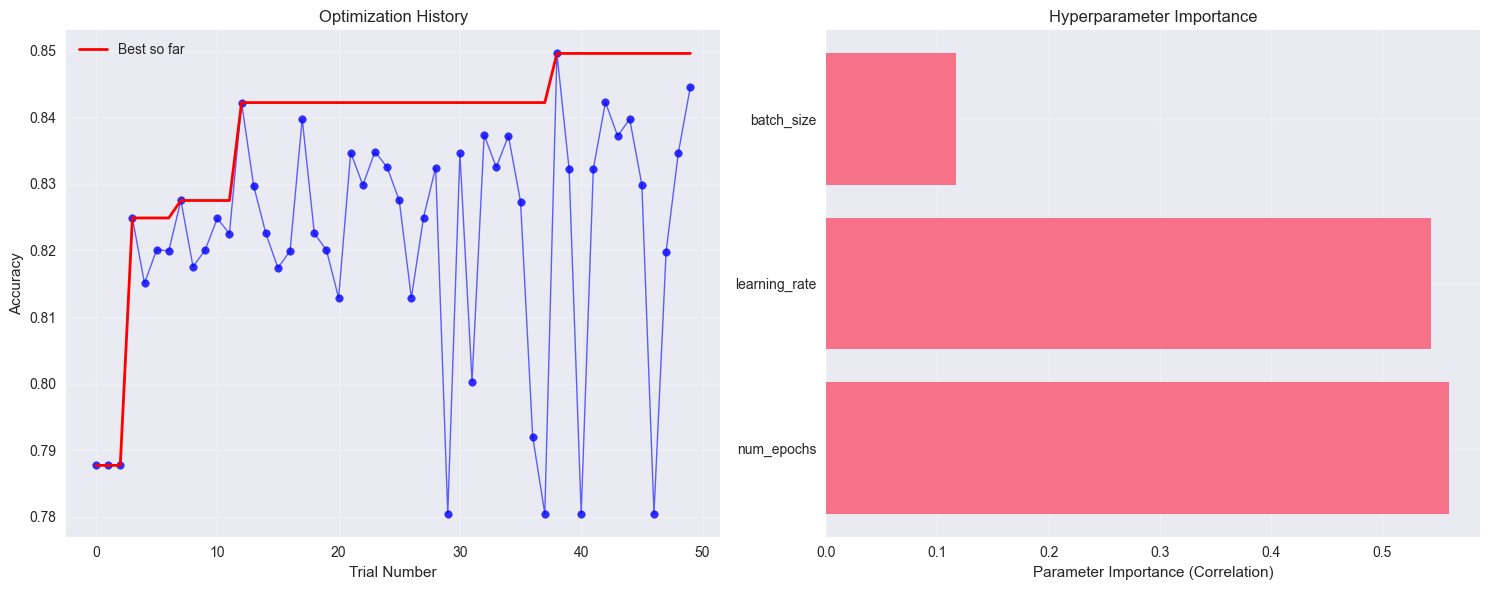

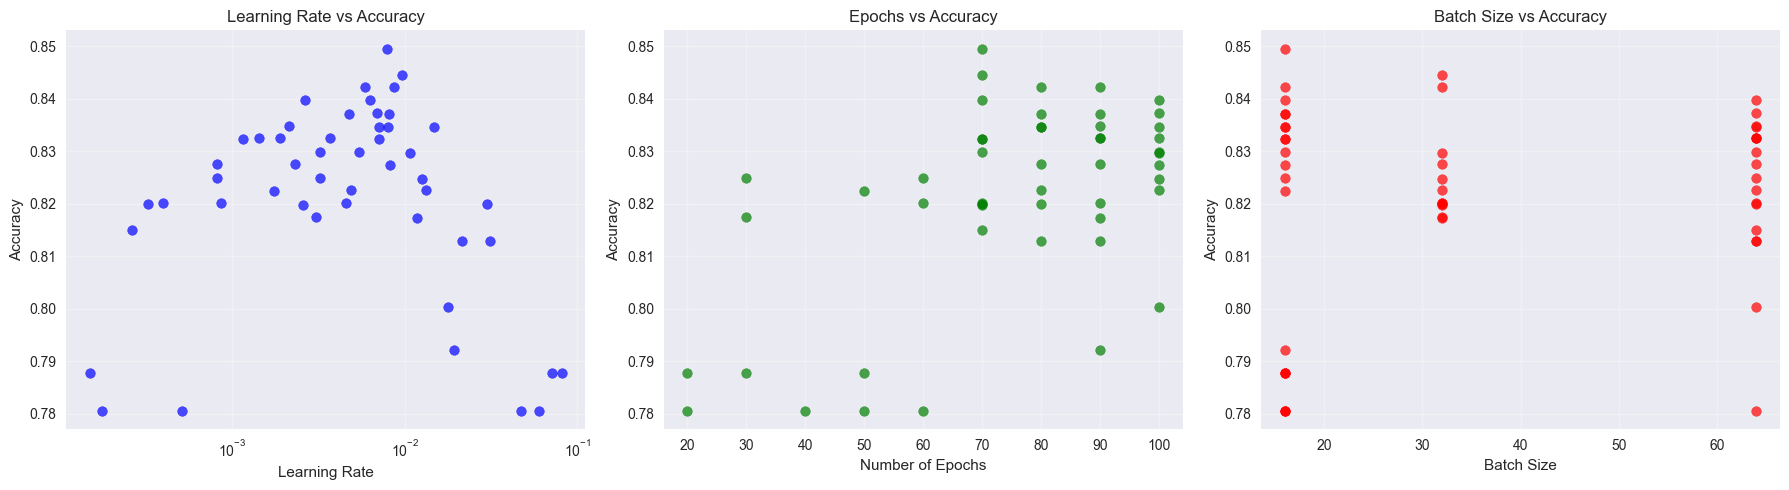

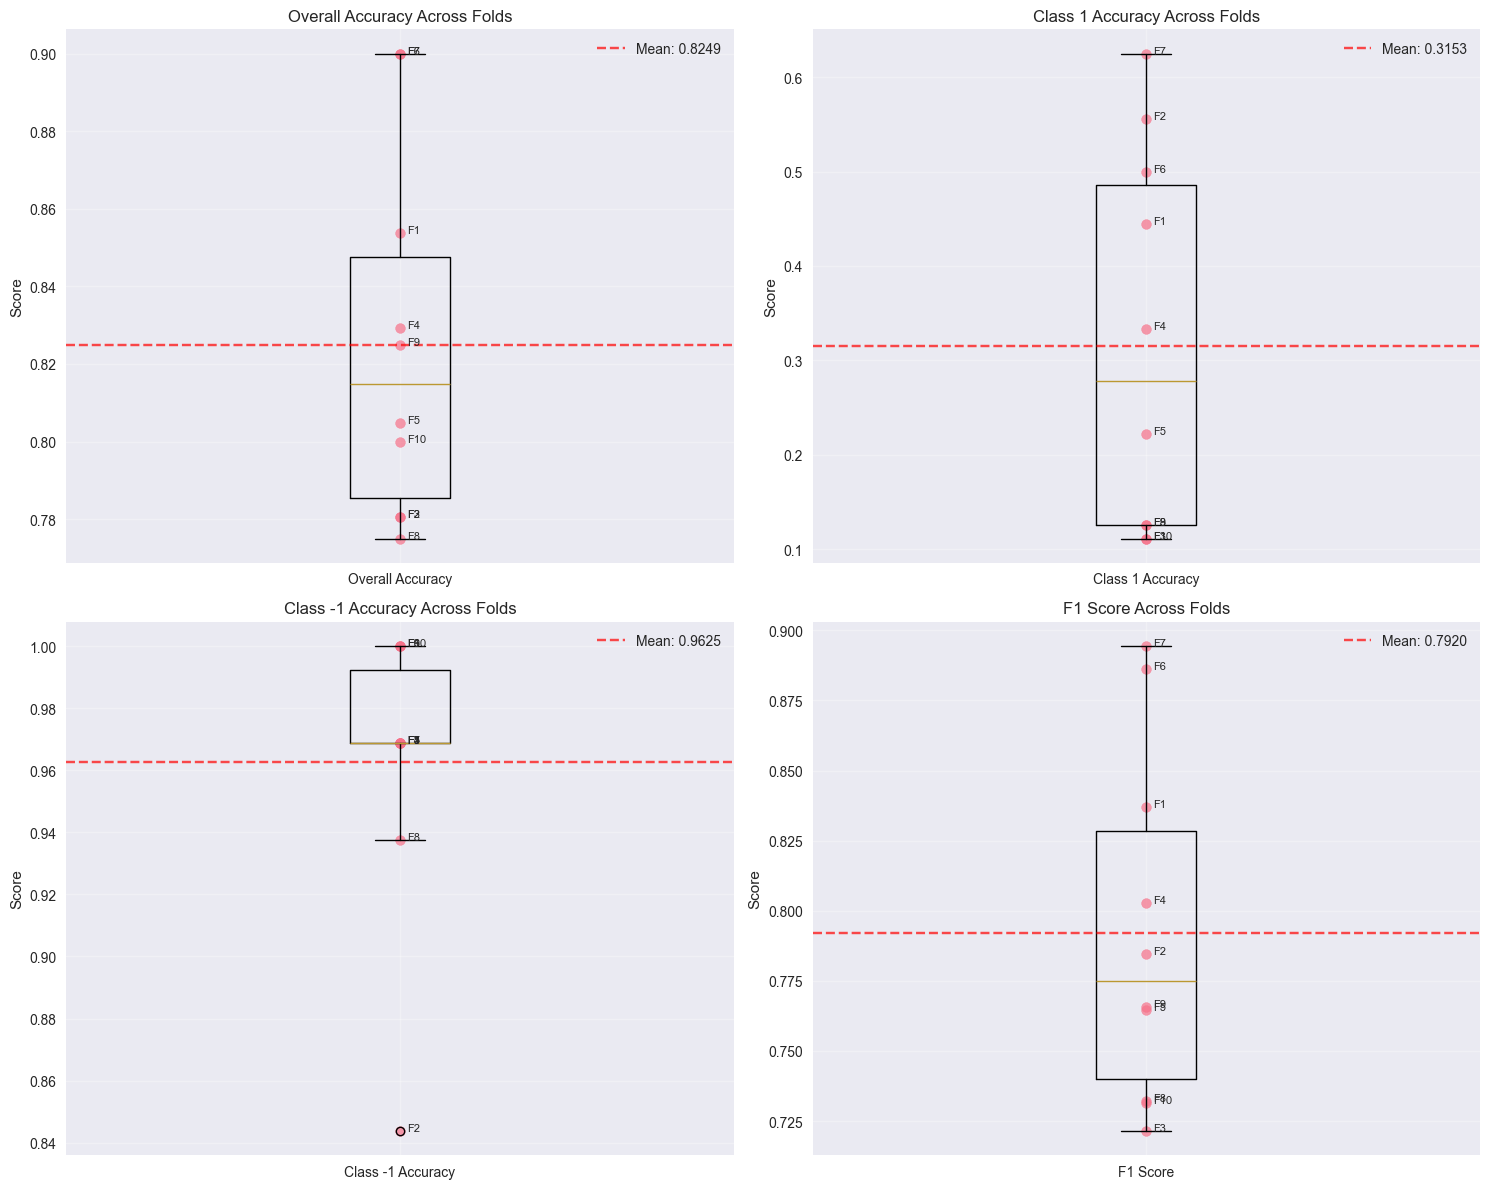


Training final model for detailed evaluation...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


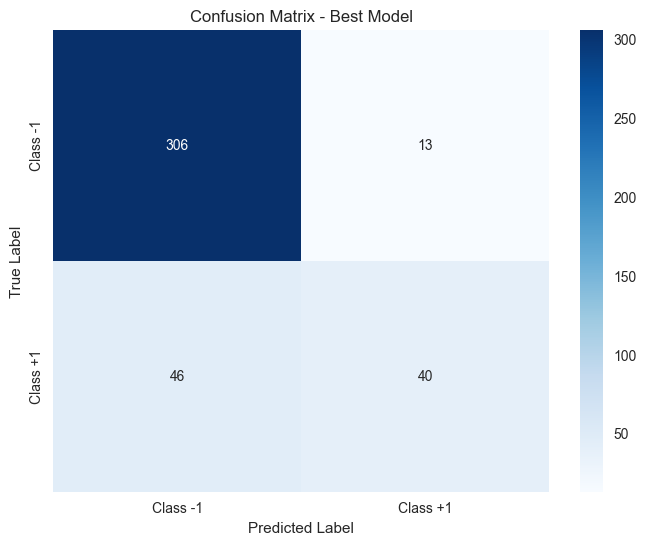

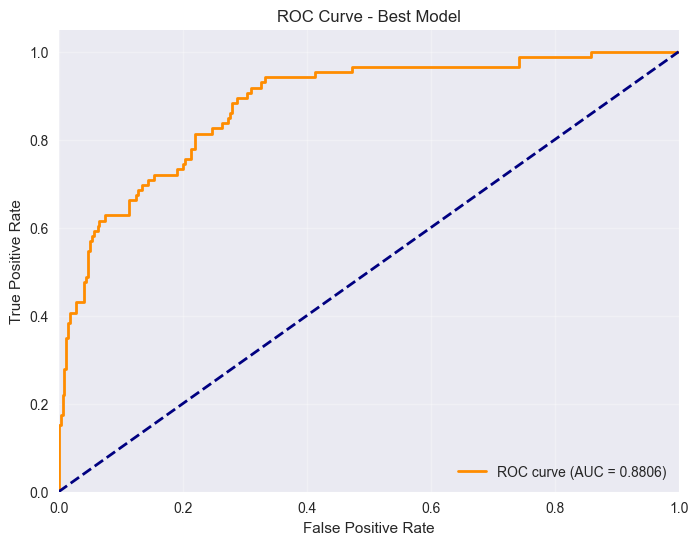

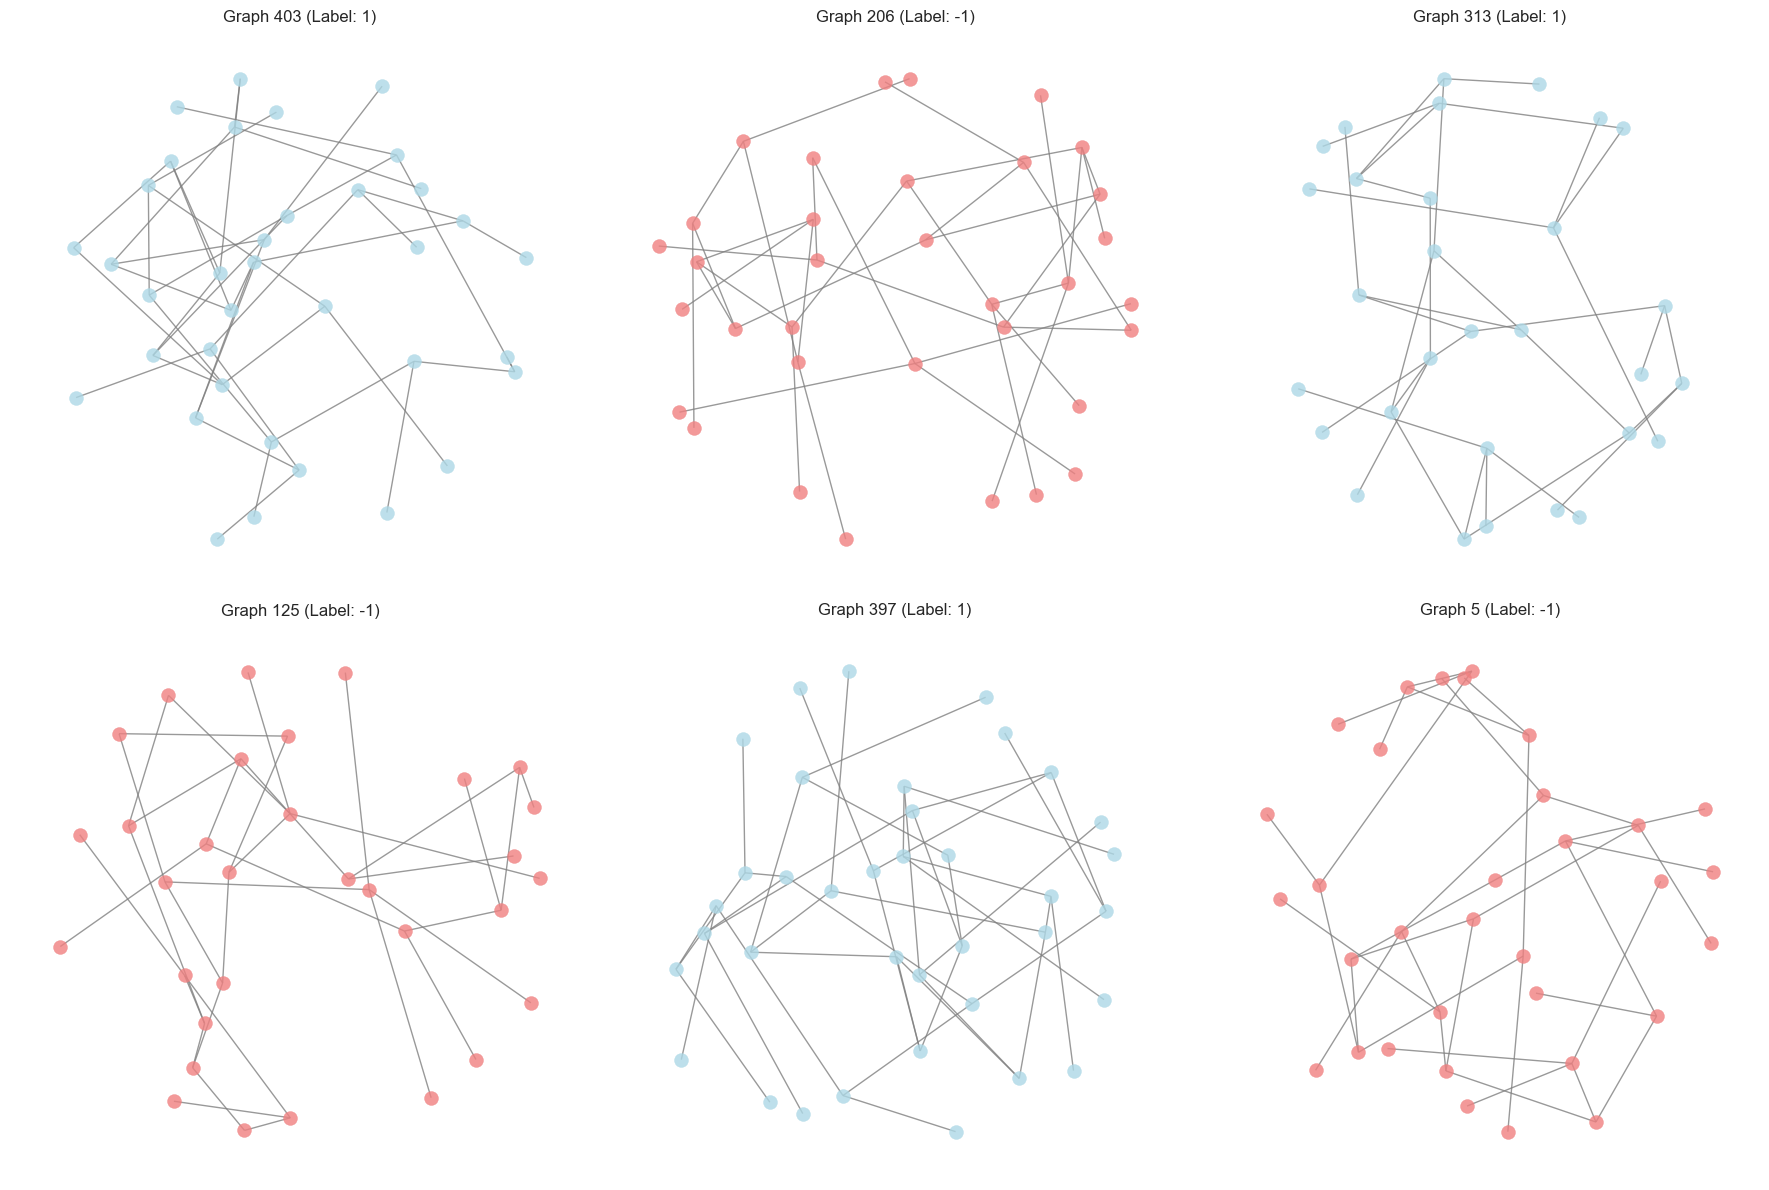

All visualizations have been generated and saved!


In [19]:
# Create visualizer with optimization results
visualizer = GCNResultsVisualizer(
    study=study, 
    all_results=all_results, 
    best_params=study.best_trial.params
)

# Generate core optimization visualizations
visualizer.plot_optimization_history()
visualizer.plot_hyperparameter_relationships()
visualizer.plot_cross_validation_results()

# For the final model evaluation with the best parameters
print("\nTraining final model for detailed evaluation...")

# Use the entire dataset for final model evaluation
final_train_loader = DataLoader(full_graph_data, batch_size=final_batch_size, shuffle=True)
final_model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=final_learning_rate)
final_criterion = nn.CrossEntropyLoss()

# Train the final model
for epoch in range(final_num_epochs):
    train_loss = train_model(final_model, final_train_loader, final_optimizer, final_criterion, device)

# Get predictions and probabilities for visualization
final_y_true, final_y_scores = get_model_probabilities(final_model, final_train_loader, device)
final_y_pred = np.argmax(final_y_scores, axis=1) * 2 - 1  # Convert back to {-1, 1}

# Generate performance visualizations
visualizer.plot_confusion_matrix(final_y_true, final_y_pred)
visualizer.plot_roc_curve(final_y_true, final_y_scores)

# Visualize sample graphs
visualizer.plot_sample_graphs(graphs_list, labels_list)

print("All visualizations have been generated and saved!")